In [1]:
import google.generativeai as genai
from dotenv import load_dotenv
import os

load_dotenv()

genai.configure(
    api_key=os.getenv("GOOGLE_API_KEY")
)

models = genai.list_models()

for model in models:

    print(model.name)

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_14984\247550724.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-max-preview-04-2026
models/deep-research-prev

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [3]:
from langchain_core.tools import tool

In [4]:
@tool
def cheap_hotels(city:str):
    """Find cheap hotels in a city."""

    hotels = {
        "goa": [
            "Budget Beach Resort - ₹1200/night",
            "Sea View Hostel - ₹800/night",
            "Palm Stay Hotel - ₹1500/night"
        ],
        "delhi": [
            "Delhi Inn - ₹1000/night",
            "Capital Hostel - ₹700/night"
        ],
        "manali": [
            "Mountain View Hotel - ₹1300/night",
            "Snow Peak Stay - ₹900/night"
        ]
    }

    return hotels.get(city.lower(), ["No cheap hotels found"])

In [5]:
@tool
def tourist_places(city:str):
    """Suggest tourist places in a city."""

    places = {
        "goa": [
            "Baga Beach",
            "Anjuna Beach",
            "Fort Aguada"
        ],
        "manali": [
            "Solang Valley",
            "Rohtang Pass",
            "Hadimba Temple"
        ],
        "delhi": [
            "India Gate",
            "Red Fort",
            "Qutub Minar"
        ]
    }

    return places.get(city.lower(), ["No places found"])

In [6]:
@tool
def budget_estimator(days:int, budget_per_day:int):
    """Estimate total travel budget."""

    total = days * budget_per_day

    return f"Estimated budget is ₹{total}"

In [7]:
@tool
def weather(city:str):
    """Get weather information."""

    weather_data = {
        "goa": "28°C Sunny",
        "delhi": "35°C Hot",
        "manali": "12°C Cold"
    }

    return weather_data.get(city.lower(), "Weather unavailable")

In [8]:
from langchain_community.tools.tavily_search import TavilySearchResults

search_tool = TavilySearchResults(max_results=5)

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_8548\812494973.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(max_results=5)


In [9]:
tools = [
    cheap_hotels,
    tourist_places,
    budget_estimator,
    weather,
    search_tool
]

In [10]:
llm_with_tools = llm.bind_tools(tools)


from typing import TypedDict
from langgraph.graph.message import add_messages
from typing_extensions import Annotated

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [11]:
from langchain_core.messages import AIMessage


def assistant(state: State):

    response = llm_with_tools.invoke(state["messages"])

    return {
        "messages": [response]
    }

In [12]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [13]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

In [14]:
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

In [15]:
builder.add_edge(START, "assistant")

In [16]:
builder.add_conditional_edges(
    "assistant",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
)

In [17]:
builder.add_edge("tools", "assistant")

In [18]:
graph = builder.compile()

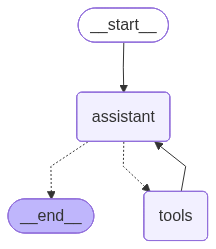

In [19]:
from IPython.display import Image, display


display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
from langchain_core.messages import HumanMessage

messages = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content="Plan a cheap 3-day Goa trip with hotels and tourist places"
            )
        ]
    }
)

In [21]:
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Plan a cheap 3-day Goa trip with hotels and tourist places
================================== Ai Message ==================================
Tool Calls:
  budget_estimator (3a3dm6w2w)
 Call ID: 3a3dm6w2w
  Args:
    budget_per_day: 500
    days: 3
  cheap_hotels (ph9hqdrwm)
 Call ID: ph9hqdrwm
  Args:
    city: Goa
  tourist_places (jxpb7js8s)
 Call ID: jxpb7js8s
  Args:
    city: Goa
================================= Tool Message =================================
Name: budget_estimator

Estimated budget is ₹1500
================================= Tool Message =================================
Name: cheap_hotels

["Budget Beach Resort - ₹1200/night", "Sea View Hostel - ₹800/night", "Palm Stay Hotel - ₹1500/night"]
================================= Tool Message =================================
Name: tourist_places

["Baga Beach", "Anjuna Beach", "Fort Aguada"]
================================== Ai Message =

In [27]:
for event in graph.stream(
    {
        "messages": [
            HumanMessage(
                content="What are the latest travel restrictions in Dubai?"
            )
        ]
    },
    stream_mode="values"
):

    last_message = event["messages"][-1]

    if hasattr(last_message, "pretty_print"):
        last_message.pretty_print()

================================ Human Message =================================

What are the latest travel restrictions in Dubai?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (dg6j71rws)
 Call ID: dg6j71rws
  Args:
    query: latest travel restrictions in Dubai
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "United Arab Emirates International Travel Information", "url": "https://travel.state.gov/content/travel/en/international-travel/International-Travel-Country-Information-Pages/UnitedArabEmirates.html", "content": "Current restrictions:\n\nWeapons and Law Enforcement Equipment: The transportation of arms or items that may be considered law enforcement or military equipment is strictly prohibited without written approval from the UAE government. Do not transport any arms or items that may be considered law enforcement or military